In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.3f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


V_current_level = 235.,235.,355.,290.,275.,230.,205.,185.,120.,230.,230.,215.,230.,230.,230. #Leakage current measured at this V
V_current_monitor = V_current_level #Voltage up to which the current level is monitored
VBD_expected = 240.,240.,240.,240.,240.,240.,240.,240.,240.,240. # expected breakdown voltage. The first element corresponds to the first wafer in the dataset, as defined by the variable "start_wafer" below.
VBD_expected_sigma = 12.,12.,12.,12.,12.,12.,12.,12.,12.,12. # expected spread of the breakdown voltage distribution. The first element corresponds to the first wafer in the dataset, as defined by the variable "start_wafer" below.
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 50. #sensor discarded if I > I_thr [uA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [uA]
I_compliance_minimum = 0.005 # [uA] VBD calculation performed only if compliance was set above this threshold
k_thr = 20. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E6 # conversion from [A] (raw data) to [uA] (used in the final plots)
start_bd_calculation = 5 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 0.001  #low and high ranges for I@100V plot [uA]
high_iv_range = 10
low_vbd_range = 0 #low and high ranges for VBD plot [V]
high_vbd_range = 300
n_wafer = 10 #
n_row = 7 #
n_col = 8 # 
start_wafer = 3 #first wafer number in the dataset
start_row = 2 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
bnoisy = False
save = False
verbose = True
write_json = False  #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2024, 6, 20, 12, 0, 0) # choose the correct date to be insterted in the json files that will be uploaded to the database. Please note each json file has a single date, so tests performed in different days should be uploaded as different json files
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

invert_polarity=True

#file_qa = root.TFile.Open("/Users/icosivi/Desktop/LC2_W12.root")
file_qa = root.TFile.Open("/Users/icosivi/Desktop/pippo.root")
tree_qa = file_qa.Get("Tree")
  
counter_qa = 0
I_qa_100V = 0.

tests_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_i_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_serialn = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
hI_qa_100V = []
hcount_qa = []
min_I = []
hiMax = []

for i in range(n_wafer):
    hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+start_wafer), r"IGR@V_{MaxOp} ETL site W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    #hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+start_wafer), r"Ipad@V_{MaxOp} ETL site W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    min_I.append(1000)

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False



if(write_json):
    json_filename="ETL_site_IV"
    
save_path = '/Users/icosivi/Desktop/plot_UFSDLF/'

In [ ]:
# run this block to analyze I_PAD1. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    dumb_counter+=1
    if(int(event.I_PAD1.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD1.at(event.I_PAD1.size()-1)<0 ): 
        Iback = [abs(i) for i in event.I_PAD1]
        #Iback = [float(-i) for i in event.I_PAD1]
        for idx, i in enumerate(event.I_PAD1):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.I_PAD1]
        #Iback = [i for i in event.I_PAD1]
        for idx, i in enumerate(event.I_PAD1):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD1.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD1.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        
        type_counter = 0
        type_counter_I_qa = 0
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<(Vbias[len(Iback)-1]-10) and Vbias[i]>=(Vbias[len(Iback)-1]-10) ):
            if( Vbias[i]==Vbias[len(Iback)-1]-10 ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((Vbias[len(Iback)-1]-10)-Vbias[i]) + Iback[i]
            break
          	
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          hiMax.append(float(I_qa_100V))    
      else:
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
# run this block to analyze I_PAD2. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    dumb_counter+=1
    if(int(event.I_PAD2.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD2.at(event.I_PAD2.size()-1)<0 ): 
        Iback = [abs(i) for i in event.I_PAD2]
        #Iback = [float(-i) for i in event.I_PAD2]
        for idx, i in enumerate(event.I_PAD2):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.I_PAD2]
        #Iback = [i for i in event.I_PAD2]
        for idx, i in enumerate(event.I_PAD2):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD2.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD2.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        
        type_counter = 0
        type_counter_I_qa = 0
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<(Vbias[len(Iback)-1]-10) and Vbias[i]>=(Vbias[len(Iback)-1]-10) ):
            if( Vbias[i]==Vbias[len(Iback)-1]-10 ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((Vbias[len(Iback)-1]-10)-Vbias[i]) + Iback[i]
            break
            
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          hiMax.append(float(I_qa_100V))    
      else:
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
# run this block to analyze I_PAD3. Please run only of of the blocks (I_PAD1 || I_PAD2 || I_PAD3)
for event in tree_qa:
    dumb_counter+=1
    if(int(event.I_PAD3.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_PAD3.at(event.I_PAD3.size()-1)<0 ): 
        Iback = [abs(i) for i in event.I_PAD3]
        #Iback = [float(-i) for i in event.I_PAD3]
        for idx, i in enumerate(event.I_PAD3):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.I_PAD3]
        #Iback = [i for i in event.I_PAD3]
        for idx, i in enumerate(event.I_PAD3):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_PAD3.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_PAD3.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        
        type_counter = 0
        type_counter_I_qa = 0
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<(Vbias[len(Iback)-1]-10) and Vbias[i]>=(Vbias[len(Iback)-1]-10) ):
            if( Vbias[i]==Vbias[len(Iback)-1]-10 ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((Vbias[len(Iback)-1]-10)-Vbias[i]) + Iback[i]
            break
            
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          hiMax.append(float(I_qa_100V))    
      else:
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [3]:
# run this block to analyze IGR. Please run only one of the blocks (I_PAD1 || I_PAD2 || I_PAD3 || IGR)
for event in tree_qa:
    dumb_counter+=1
    if(int(event.IGR.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.IGR.at(event.IGR.size()-1)<0 ): 
        Iback = [abs(i) for i in event.IGR]
        #Iback = [float(-i) for i in event.IGR]
        for idx, i in enumerate(event.IGR):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.IGR]
        #Iback = [i for i in event.IGR]
        for idx, i in enumerate(event.IGR):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.IGR.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.IGR.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        
        type_counter = 0
        type_counter_I_qa = 0
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<(Vbias[len(Iback)-1]-10) and Vbias[i]>=(Vbias[len(Iback)-1]-10) ):
            if( Vbias[i]==Vbias[len(Iback)-1]-10 ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((Vbias[len(Iback)-1]-10)-Vbias[i]) + Iback[i]
            break
            
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          hiMax.append(float(I_qa_100V))    
      else:
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
import statistics

print(statistics.mean(hiMax))
print(statistics.stdev(hiMax))

In [4]:
serial_num_counter=0

for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          #if( i==0 ):
          if( i<20 ):
             if(vcount_i_qa[i][j][k]!=0): 
               hI_qa_100V[i].Fill( j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )

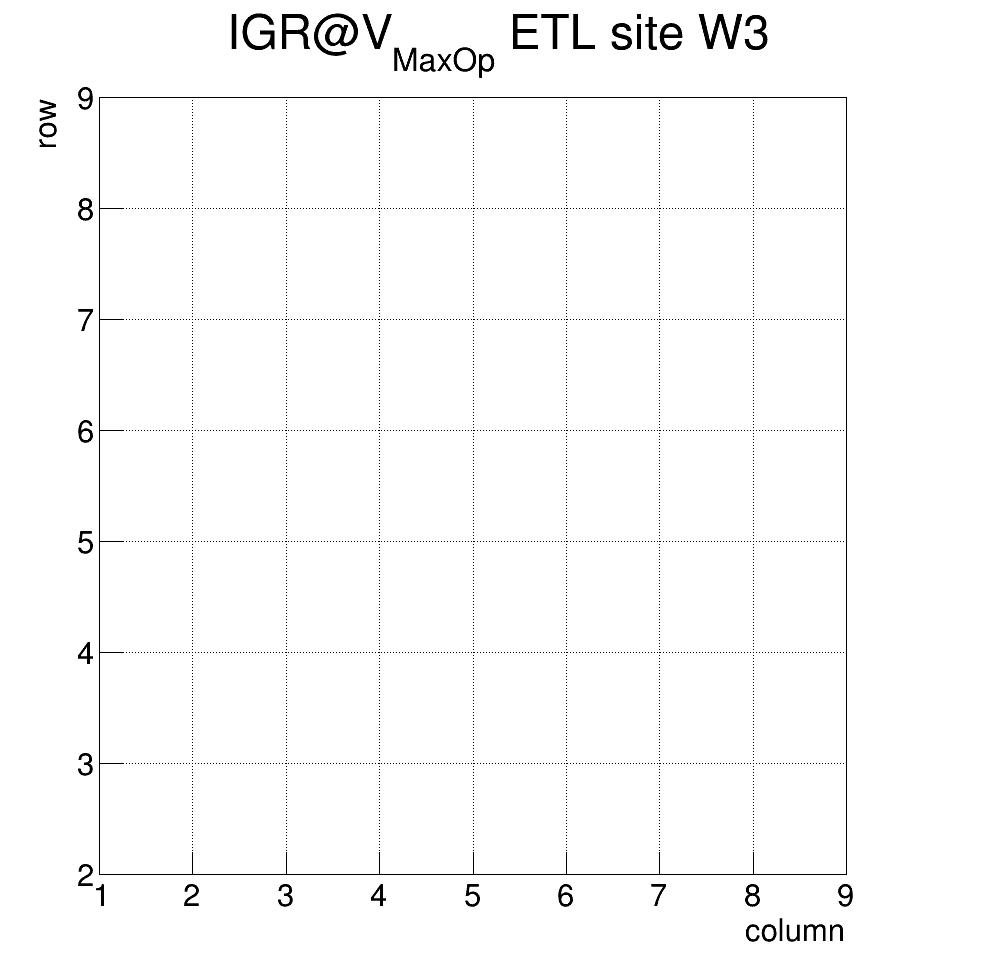

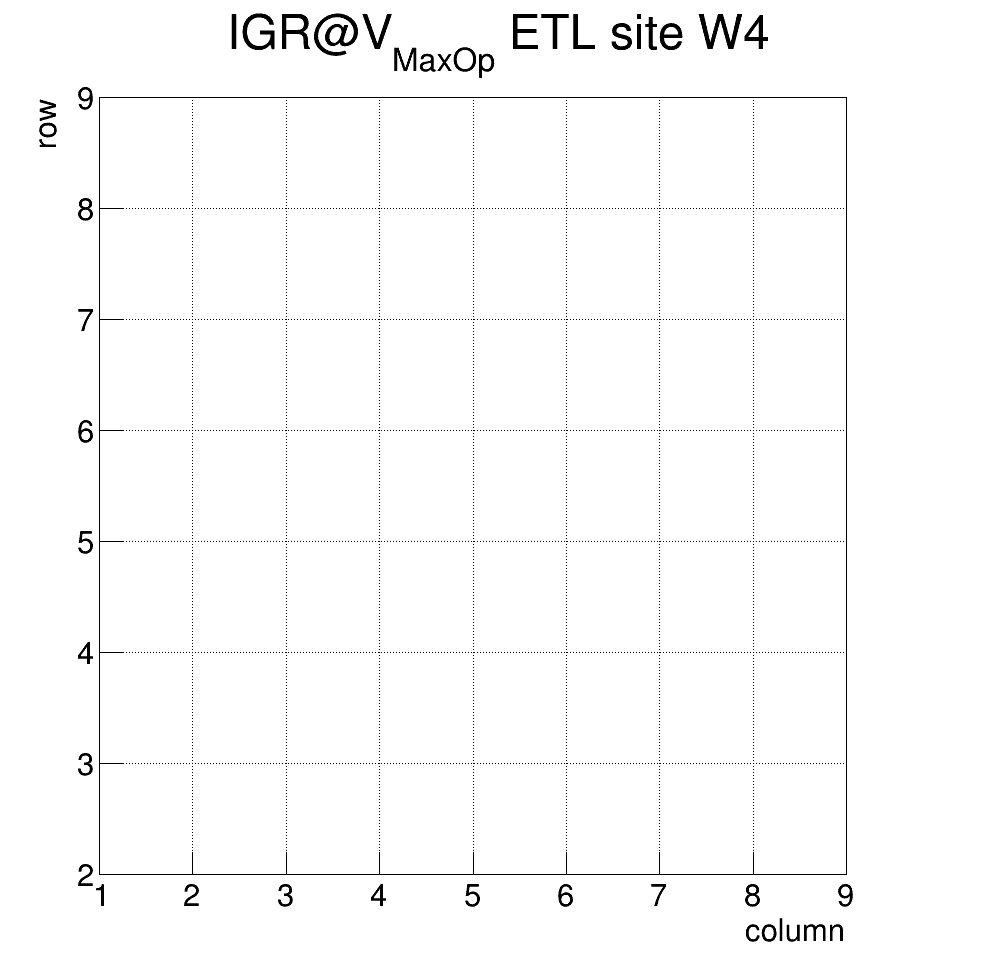

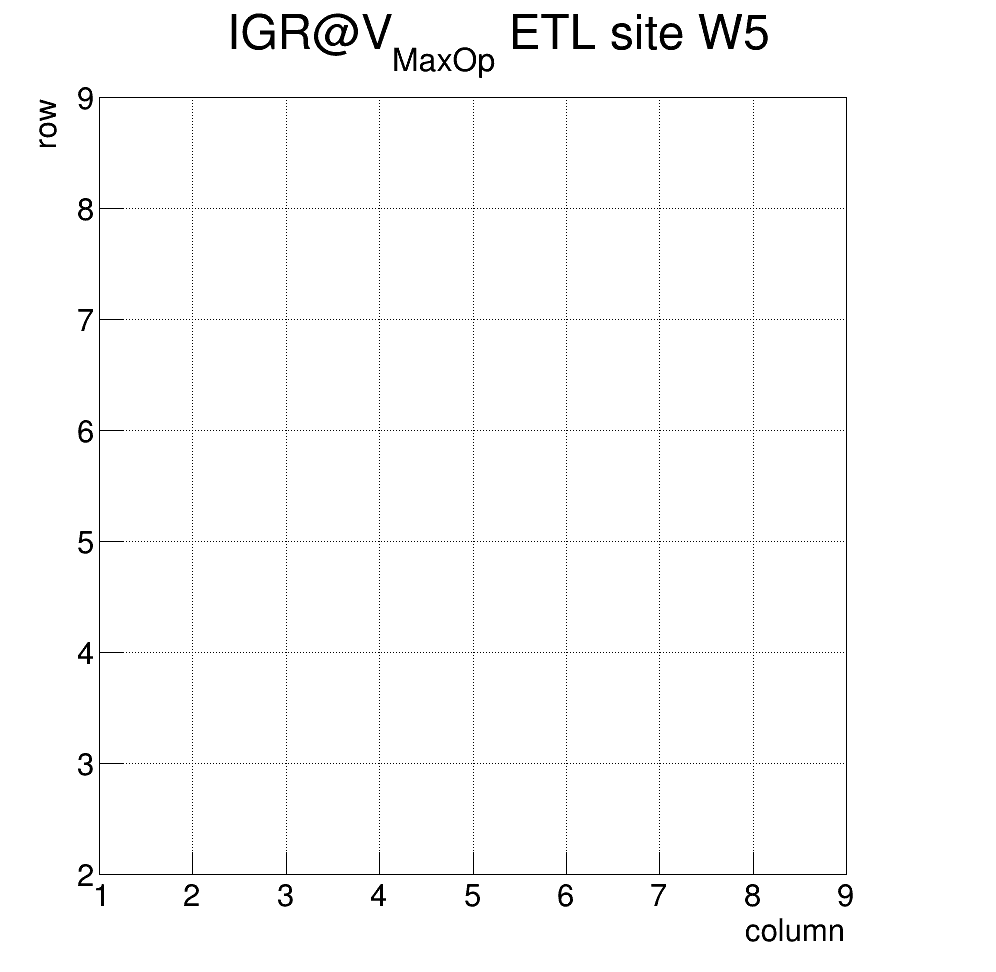

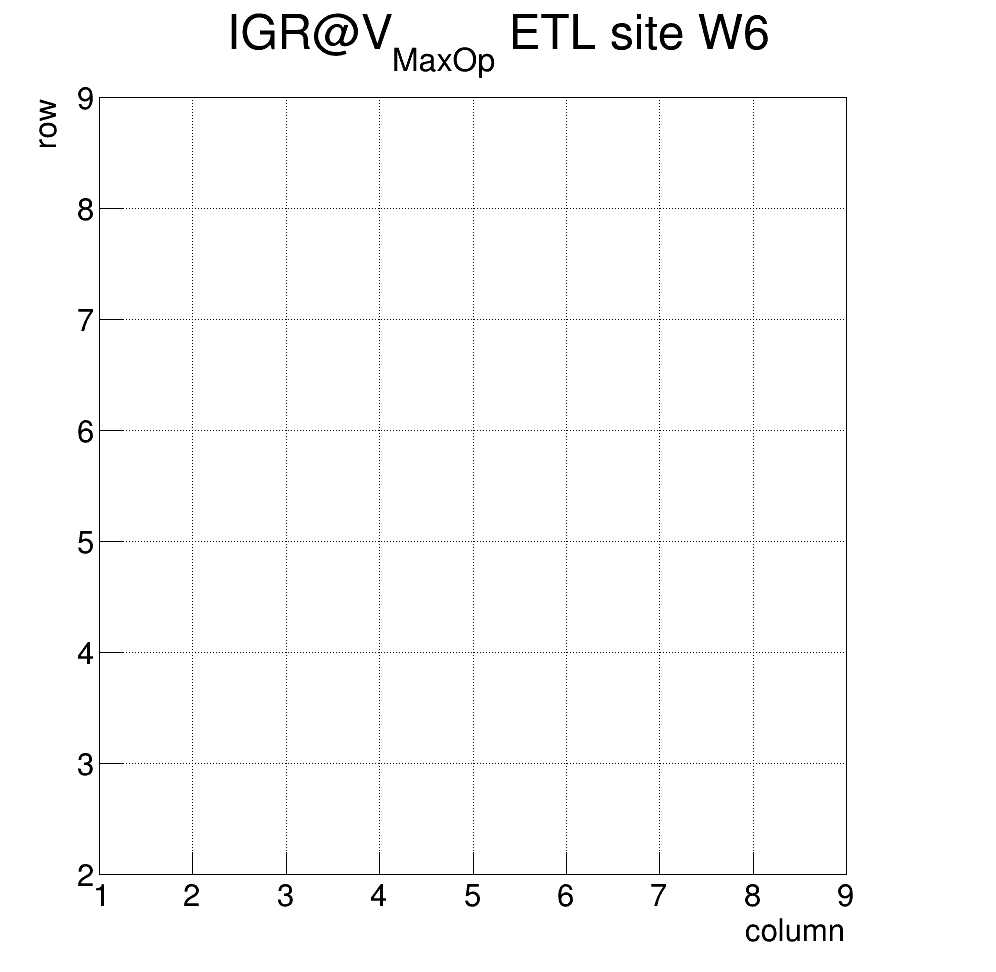

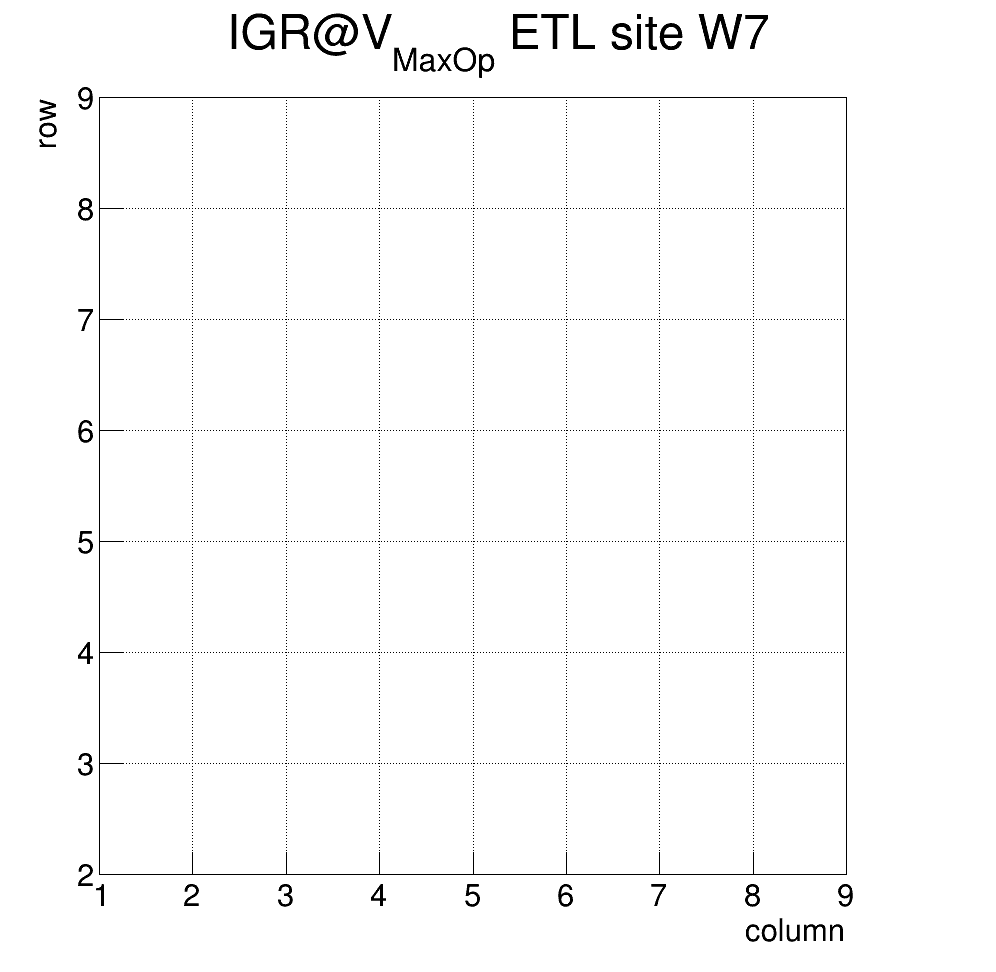

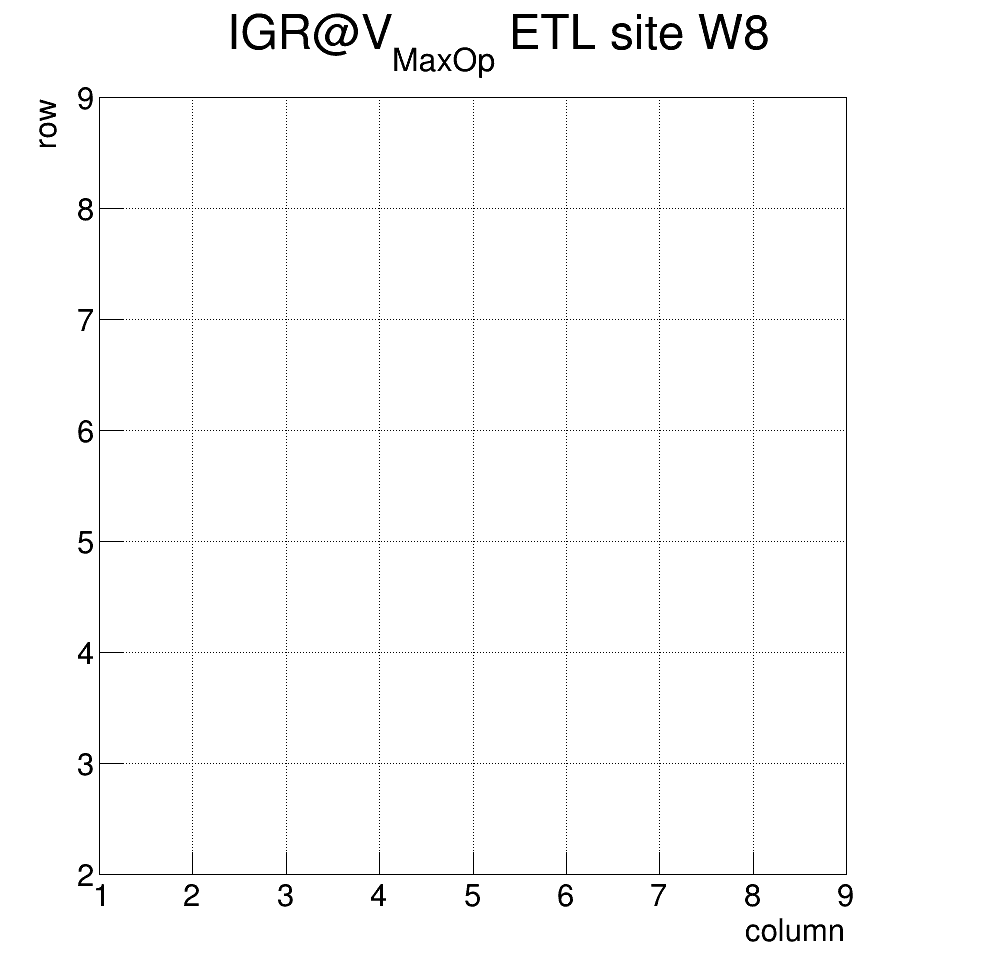

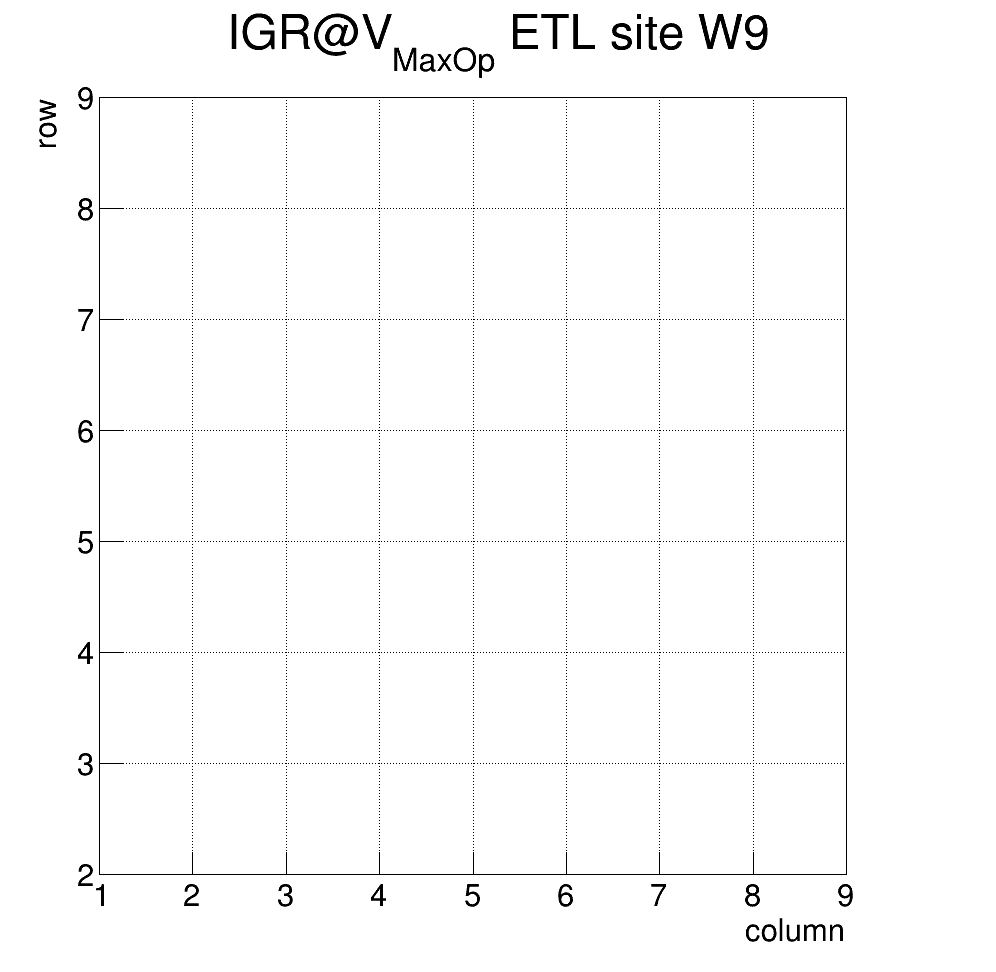

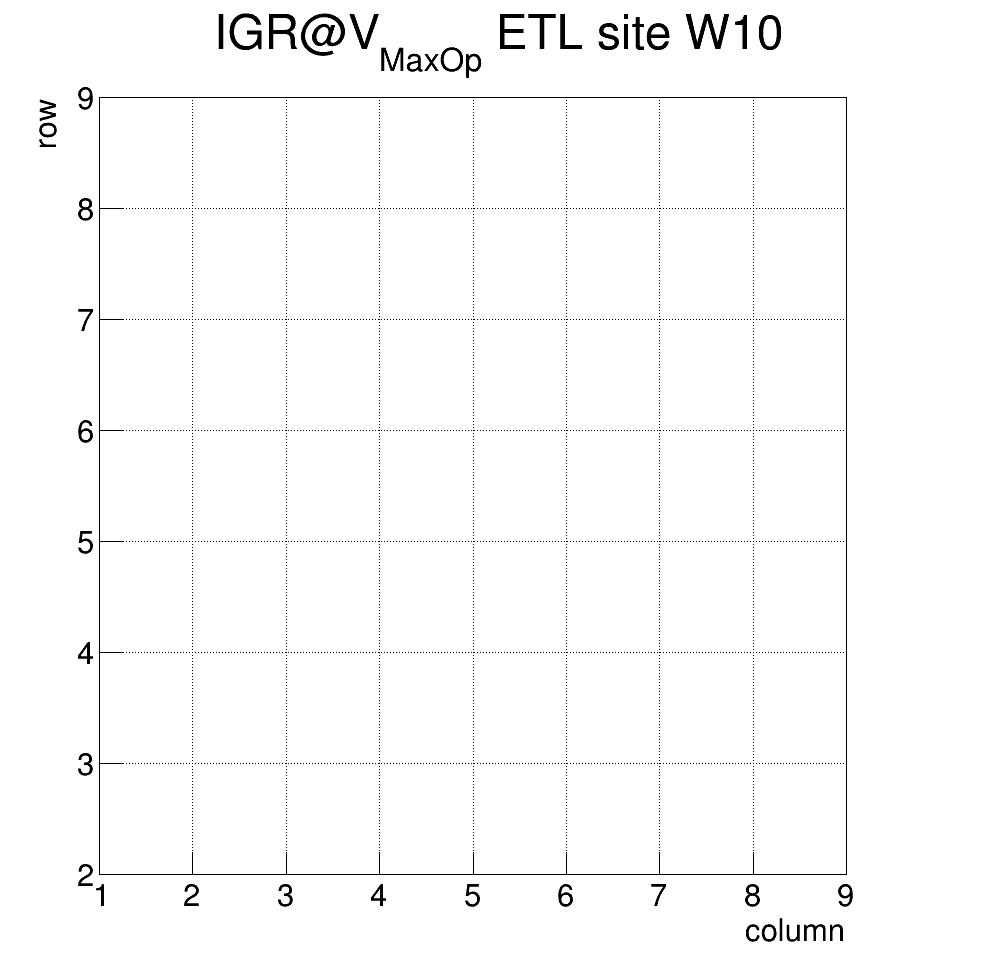

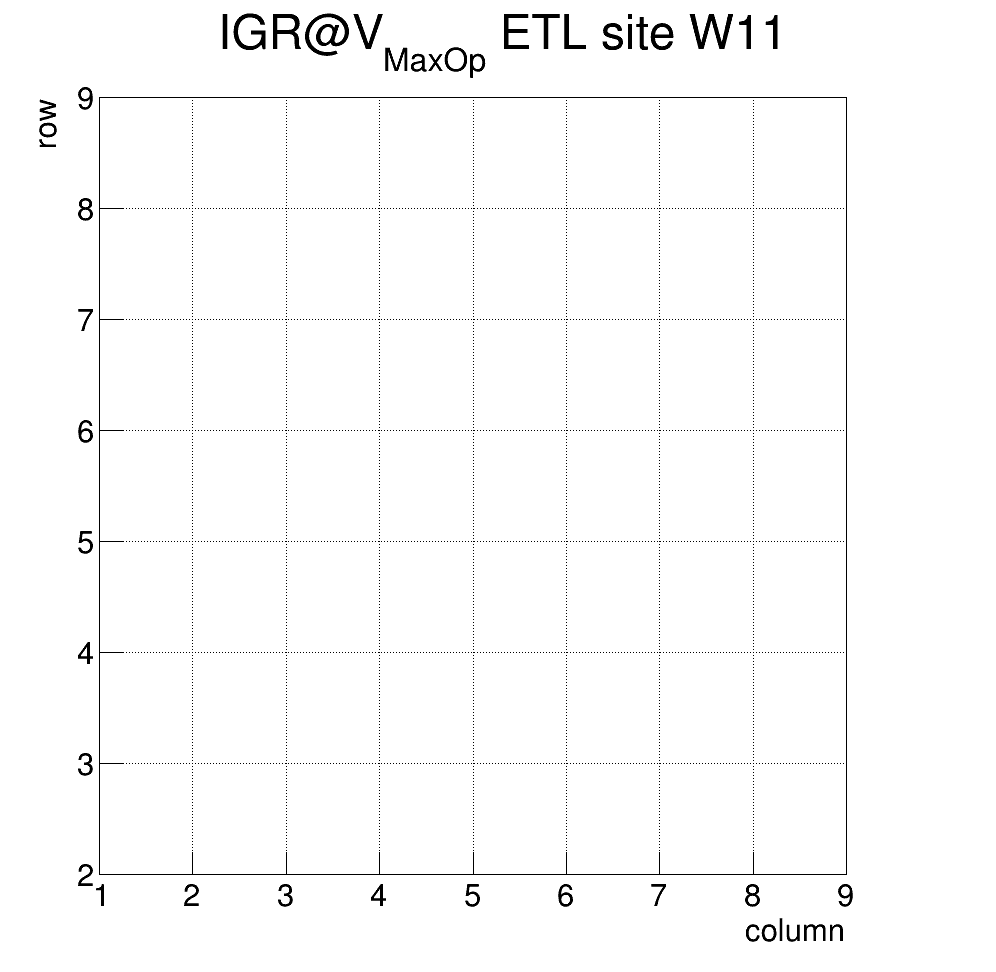

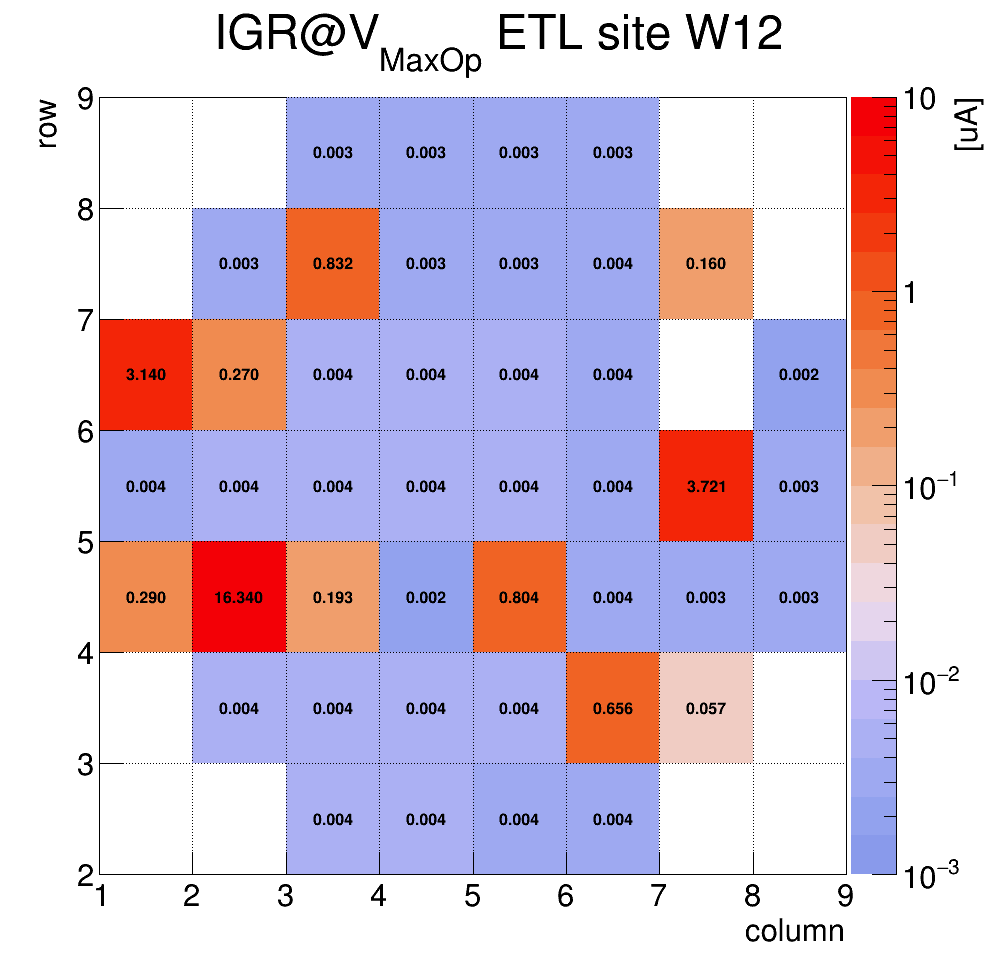

In [5]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cI_100V = []

for i in range(n_wafer):
    cI_100V.append(root.TCanvas("c_I_V_W"+str(i+start_wafer), r"c I@V_{MaxOp} ETL site W"+str(i+start_wafer), 1000,1000))


for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

    #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
    cI_100V[i].SetRightMargin(0.15)
    cI_100V[i].cd()
    hI_qa_100V[i].SetMarkerSize(0.9)
    hI_qa_100V[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.SetLogz(1)
    root.gPad.Update()
    cI_100V[i].Update()
    hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
    hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
    if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        cI_100V[i].SaveAs(save_path+"I_V_W"+str(i+start_wafer)+".png")

In [ ]:
cI_100V = []
cV = []
cbump = []
cnoisy = []

for i in range(n_wafer):
  if(bcurrent):
    cI_100V.append(root.TCanvas("c_I_"+str(V_current_level[i])+"V_W"+str(i+1), "c I@"+str(V_current_level[i])+"V_W"+str(i+1), 1000,1000))
  if(bvoltage):
    cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
  if(bcategory):
    cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
  if(bnoisy):
    cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))


for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

  
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")

    hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
    hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
    hnoisy_qa[i].GetXaxis().SetTitle("column")
    hnoisy_qa[i].GetYaxis().SetTitle("row")


    if(bcurrent):
      #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
      cI_100V[i].SetRightMargin(0.15)
      cI_100V[i].cd()
      hI_qa_100V[i].SetMarkerSize(0.9)
      hI_qa_100V[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.SetLogz(1)
      root.gPad.Update()
      cI_100V[i].Update()
      hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
      hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
  
      if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level[i])+"V_W"+str(i+1)+".png")


    if(bvoltage):
      root.gStyle.SetPaintTextFormat("1.1f")
      #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
      cV[i].SetRightMargin(0.15)
      cV[i].cd()
      hV_qa[i].SetMarkerSize(0.9)
      hV_qa[i].Draw("textcolz")
      #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cV[i].Update()
      hV_qa[i].GetXaxis().SetNdivisions(n_col)
      hV_qa[i].GetYaxis().SetNdivisions(n_row)
  
      if(save): 
        #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
        cV[i].SaveAs(save_path+"VBD_W"+str(i+1)+".png")


    if(bcategory):
      #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
      cbump[i].SetRightMargin(0.15)
      cbump[i].cd()
      hbump_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cbump[i].Update()
      hbump_qa[i].GetXaxis().SetNdivisions(n_col)
      hbump_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
        cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+".png" )   


    if(bnoisy):
      #cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))
      cnoisy[i].SetRightMargin(0.15)
      cnoisy[i].cd()
      hnoisy_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cnoisy[i].Update()
      hnoisy_qa[i].GetXaxis().SetNdivisions(n_col)
      hnoisy_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        cnoisy[i].SaveAs("pics/noisy_W"+str(i+1)+".png")

In [ ]:
#Script to get the Wafer, row, col given the Serial Number as input

from openpyxl import load_workbook

#sserial = 'FBK_LF1_ROL_030'
#pippo_coord = str( wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Wafer'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Column'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Row'].iloc[0] )
# print(pippo_coord)
#str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Row'] == k+start_row) & (wb['Column'] == j+start_col)]['SerialNumber'].iloc[0])

workbook = load_workbook('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')
worksheet = workbook.active  # Assuming you want to search the active sheet

for row in worksheet.iter_rows():
    for cell in row:
      if cell.value == 'FBK_LF1_ROL_030':
        for idd, cell in enumerate(row):
          if idd==4 or idd==6 or idd==7 :
           print(cell.value, end=" ")
        print()

In [ ]:
#Script to produce a xlsx file with a subset of sensors, based on conditions that can be specified

import pandas as pd

# Read the original Excel file
wb = pd.read_excel('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')

# Filter the DataFrame based on your condition
# For example, to filter rows where the value in column 'A' is greater than 10:
filtered_df = wb[wb['Wafer'] == 8]

# Write the filtered DataFrame to a new Excel file
filtered_df.to_excel("/Users/icosivi/Desktop/UFSDLF_16x16_W8.xlsx", index=False)
